<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session27: PCA</font></h3>
<h3 align="center">Zahra Amini</h3>

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA

In [5]:
X = np.random.randint(10, 50, 100).reshape(20, 5)

In [7]:
X.shape

(20, 5)

In [9]:
X_mean = X - np.mean(X, axis=0)

In [11]:
cov_matrix = np.cov(X_mean, rowvar = False)

In [13]:
eigen_value, eigen_vector =np.linalg.eigh(cov_matrix)

In [16]:
sorted_index = np.argsort(eigen_value)[::-1]

In [17]:
sorted_eigenvalue = eigen_value[sorted_index]

In [18]:
sorted_eigentvector = eigen_vector[:, sorted_index]

In [19]:
n_com = 2

In [20]:
eigenvector_sub = sorted_eigentvector[:, :n_com]

In [21]:
X_red = np.dot(eigenvector_sub.T, X_mean.T).T

In [23]:
X_red.shape

(20, 2)

# PCA Iris

In [36]:
def PCA_model(X, n_com):
    
    #1
    X_mean = X-np.mean(X, axis=0)
    
    #2
    Cov_matrix = np.cov(X_mean, rowvar=False)
    
    #3
    eig_value, eig_vector = np.linalg.eigh(Cov_matrix)
    
    #4
    sort_index = np.argsort(eig_value)[::-1]
    
    sort_eignvalue = eig_value[sort_index]
    
    sort_eignvector = eig_vector[:, sort_index]
    
    #5
    eignvector_sub = sort_eignvector[:, 0:n_com]
    
    #6
    X_prj = np.dot(eignvector_sub.transpose(), X_mean.transpose()).transpose()
    
    return X_prj

In [25]:
data = pd.read_csv("iris.data", 
                   names = ['sepal length', 'sepal width', 'petal length', 'petal width', 'target'])

In [26]:
data

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [27]:
x = data.iloc[:, 0:4]

In [28]:
target = data.iloc[:, 4]

In [29]:
target

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: target, Length: 150, dtype: object

In [37]:
X_reduced = PCA_model(x, 2)

In [39]:
X_reduced.shape

(150, 2)

In [40]:
pca_df = pd.DataFrame(X_reduced, columns = ['PC1', 'PC2'])

In [42]:
pca_df1 = pd.concat([pca_df, pd.DataFrame(target)], axis=1)

In [43]:
pca_df1

,PC1,PC2,target
0,2.684207,0.326607,Iris-setosa
1,2.715391,-0.169557,Iris-setosa
2,2.889820,-0.137346,Iris-setosa
3,2.746437,-0.311124,Iris-setosa
4,2.728593,0.333925,Iris-setosa
...,...,...,...
145,-1.944017,0.187415,Iris-virginica
146,-1.525664,-0.375021,Iris-virginica
147,-1.764046,0.078519,Iris-virginica
148,-1.901629,0.115877,Iris-virginica


<AxesSubplot:xlabel='PC1', ylabel='PC2'>

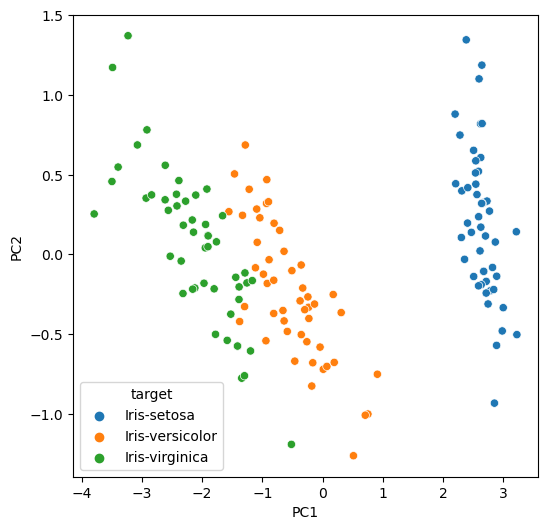

In [44]:
plt.figure(figsize = (6, 6))

sns.scatterplot(data=pca_df1, x='PC1', y='PC2', hue = 'target')

# PCA

In [45]:
pca = PCA(n_components=2)

In [46]:
X_pca = pca.fit_transform(x)

In [48]:
# X_pca

In [49]:
pca_df2 = pd.DataFrame(X_pca, columns = ['PC1', 'PC2'])

In [50]:
pca_df2

,PC1,PC2
0,-2.684207,0.326607
1,-2.715391,-0.169557
2,-2.889820,-0.137346
3,-2.746437,-0.311124
4,-2.728593,0.333925
...,...,...
145,1.944017,0.187415
146,1.525664,-0.375021
147,1.764046,0.078519
148,1.901629,0.115877


In [51]:
pca_df2 = pd.concat([pca_df2, pd.DataFrame(target)], axis=1)

<AxesSubplot:xlabel='PC1', ylabel='PC2'>

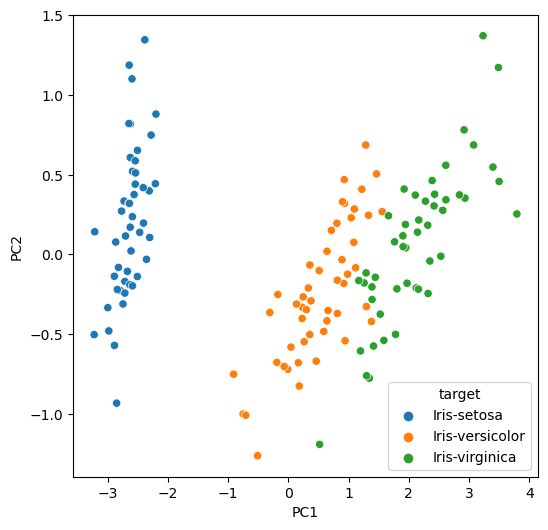

In [52]:
plt.figure(figsize = (6, 6))

sns.scatterplot(data=pca_df2, x='PC1', y='PC2', hue = 'target')